In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_excel("DF_FINAL.xlsx")

df.head()

calles_base = [
        "Avenida Rafaela Ybarra",
        "Avenida de Oporto",
        "Calle Alcocer",
        "Calle Embajadores",
        "Calle Méndez Álvaro",
        "Calle Ronda de Valencia",
        "Calle Silvano",
        "Calle Toledo",
        "Calle de Gran Vía de San Francisco",
        "Calle de Marcelo Usera",
        "Paseo de Extremadura",
        "Paseo de Santa María de la Cabeza"
]

calles_sur = []

for base in calles_base:
    for col in df.columns:
        if base in col:
            calles_sur.append(col)

L = 3  # número de lags

X = pd.DataFrame()

for street in calles_sur:
    for lag in range(1, L + 1):
        X[f"{street}_t-{lag}"] = df[street].shift(lag)

# Variables externas reales
X["AEMET_tmed"] = df["AEMET_tmed"]
X["AEMET_prec"] = df["AEMET_prec"]
X["dia_semana"] = df["dia_semana"]
X["festivo"] = df["festivo"]

# Convertir variables categóricas a numéricas
X["dia_semana"] = X["dia_semana"].map({
    "lunes": 0,
    "martes": 1,
    "miércoles": 2,
    "jueves": 3,
    "viernes": 4,
    "sábado": 5,
    "domingo": 6
})

X["festivo"] = X["festivo"].map({
    "no": 0,
    "sí": 1
})


y_col = [col for col in df.columns if "Calle Embajadores" in col][0]
y = df[y_col]

# Limpiar NaNs
X = X.dropna()
y = y.loc[X.index]

In [3]:
# División temporal (80% train, 20% test)
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape, X_test.shape)

(15376, 73) (3845, 73)


In [4]:
with pd.ExcelWriter("dataset_XGBoost_Embajadores.xlsx") as writer:
    X_train.to_excel(writer, sheet_name="X_train")
    X_test.to_excel(writer, sheet_name="X_test")
    y_train.to_excel(writer, sheet_name="y_train")
    y_test.to_excel(writer, sheet_name="y_test")

In [5]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [6]:
y_pred = model.predict(X_test)
# Predicción próxima hora
X_next = X.iloc[[-1]]
y_next = model.predict(X_next)

print("Predicción tráfico en Embajadores (E-O) próxima hora:", y_next[0])

Predicción tráfico en Embajadores (E-O) próxima hora: 340.52182


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 49.84
RMSE: 67.16
MAPE: 10.24%


In [8]:
importances = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head(10))

Calle Silvano_E-O_t-1                         0.510754
Calle Silvano_O-E_t-1                         0.141545
Paseo de Santa María de la Cabeza_S-N_t-1     0.056764
Calle Méndez Álvaro_N-S_t-1                   0.052773
Calle Méndez Álvaro_S-N_t-2                   0.046844
Calle Méndez Álvaro_S-N_t-1                   0.043619
Calle Embajadores_E-O_t-1                     0.016268
Calle de Gran Vía de San Francisco_S-N_t-1    0.014571
Calle Alcocer_E-O_t-3                         0.014195
Avenida Rafaela Ybarra_N-S_t-2                0.012247
dtype: float32


In [9]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=0,
    n_jobs=-1,
    scoring="neg_mean_absolute_error"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

perm_df.head(10)


,feature,importance
33,Calle Silvano_E-O_t-1,86.184068
15,Calle Embajadores_E-O_t-1,58.688512
66,Paseo de Santa María de la Cabeza_S-N_t-1,15.658692
21,Calle Méndez Álvaro_N-S_t-1,13.873660
24,Calle Méndez Álvaro_S-N_t-1,10.355047
36,Calle Silvano_O-E_t-1,4.860811
34,Calle Silvano_E-O_t-2,4.468293
48,Calle de Gran Vía de San Francisco_S-N_t-1,2.885873
71,dia_semana,0.827654
42,Calle Toledo_S-N_t-1,0.820183


In [10]:
top_k = 8
top_features = perm_df.head(top_k)
top_features


,feature,importance
33,Calle Silvano_E-O_t-1,86.184068
15,Calle Embajadores_E-O_t-1,58.688512
66,Paseo de Santa María de la Cabeza_S-N_t-1,15.658692
21,Calle Méndez Álvaro_N-S_t-1,13.873660
24,Calle Méndez Álvaro_S-N_t-1,10.355047
36,Calle Silvano_O-E_t-1,4.860811
34,Calle Silvano_E-O_t-2,4.468293
48,Calle de Gran Vía de San Francisco_S-N_t-1,2.885873


In [11]:
top_streets = (
    top_features["feature"]
    .str.split("_")
    .str[0]
    .value_counts()
)
top_streets

feature
Calle Silvano                         3
Calle Méndez Álvaro                   2
Calle Embajadores                     1
Paseo de Santa María de la Cabeza     1
Calle de Gran Vía de San Francisco    1
Name: count, dtype: int64

In [12]:
from pathlib import Path

# Cambiar estos dos valores en cada notebook
modelo = "XGBoost"
calle = "Calle Embajadores"

# Carpeta donde se guardarán las importancias
output_dir = Path("importancias_variables")
output_dir.mkdir(exist_ok=True)

# Guardar todas las variables, no solo el top 10
perm_df_export = perm_df.copy()
perm_df_export["modelo"] = modelo
perm_df_export["calle"] = calle

# Nombre limpio para el archivo
nombre_archivo = f"{modelo}_{calle}".replace(" ", "_").replace("á", "a").replace("é", "e")
nombre_archivo = nombre_archivo.replace("í", "i").replace("ó", "o").replace("ú", "u")

perm_df_export.to_csv(output_dir / f"{nombre_archivo}.csv", index=False)

print(f"Archivo guardado: {output_dir / f'{nombre_archivo}.csv'}")

Archivo guardado: importancias_variables\XGBoost_Calle_Embajadores.csv


In [13]:
calle_objetivo = "Calle Embajadores"   # cámbialo según el notebook
modelo = "XGBoost"                # opcional, para tenerlo identificado

In [14]:
import pandas as pd
import unicodedata

def normalizar_texto(texto):
    texto = str(texto).lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

def clasificar_variable(feature, calle_objetivo):
    f = normalizar_texto(feature)
    calle = normalizar_texto(calle_objetivo)

    # Variables meteorológicas
    if any(palabra in f for palabra in [
        'aemet', 'tmed', 'temp', 'temperatura', 'prec', 'precipitacion',
        'humedad', 'viento', 'presion', 'radiacion'
    ]):
        return 'Variables meteorológicas'

    # Variables de calendario
    if any(palabra in f for palabra in [
        'dia_semana', 'festivo', 'mes', 'hora', 'fin_semana'
    ]):
        return 'Variables de calendario'

    # Retardos de la propia calle
    if calle in f:
        return 'Retardos propia calle'

    # Resto de variables de tráfico
    return 'Retardos otras calles'

In [15]:
perm_df_aux = perm_df.copy()

perm_df_aux["modelo"] = modelo
perm_df_aux["calle"] = calle_objetivo

perm_df_aux["tipo_variable"] = perm_df_aux["feature"].apply(
    lambda x: clasificar_variable(x, calle_objetivo)
)

perm_df_aux.head(15)

,feature,importance,modelo,calle,tipo_variable
33,Calle Silvano_E-O_t-1,86.184068,XGBoost,Calle Embajadores,Retardos otras calles
15,Calle Embajadores_E-O_t-1,58.688512,XGBoost,Calle Embajadores,Retardos propia calle
66,Paseo de Santa María de la Cabeza_S-N_t-1,15.658692,XGBoost,Calle Embajadores,Retardos otras calles
21,Calle Méndez Álvaro_N-S_t-1,13.873660,XGBoost,Calle Embajadores,Retardos otras calles
24,Calle Méndez Álvaro_S-N_t-1,10.355047,XGBoost,Calle Embajadores,Retardos otras calles
36,Calle Silvano_O-E_t-1,4.860811,XGBoost,Calle Embajadores,Retardos otras calles
34,Calle Silvano_E-O_t-2,4.468293,XGBoost,Calle Embajadores,Retardos otras calles
48,Calle de Gran Vía de San Francisco_S-N_t-1,2.885873,XGBoost,Calle Embajadores,Retardos otras calles
71,dia_semana,0.827654,XGBoost,Calle Embajadores,Variables de calendario
42,Calle Toledo_S-N_t-1,0.820183,XGBoost,Calle Embajadores,Retardos otras calles


In [16]:
perm_df_aux["importance_pos"] = perm_df_aux["importance"].clip(lower=0)

In [17]:
resumen_tipos = (
    perm_df_aux
    .groupby("tipo_variable")["importance_pos"]
    .sum()
    .reset_index()
)

resumen_tipos["porcentaje"] = (
    100 * resumen_tipos["importance_pos"] / resumen_tipos["importance_pos"].sum()
)

resumen_tipos = resumen_tipos.sort_values("porcentaje", ascending=False)

resumen_tipos

,tipo_variable,importance_pos,porcentaje
0,Retardos otras calles,142.721514,70.172444
1,Retardos propia calle,59.439254,29.224730
2,Variables de calendario,0.827654,0.406936
3,Variables meteorológicas,0.398415,0.195890


In [18]:
meteo_df = perm_df_aux[perm_df_aux["tipo_variable"] == "Variables meteorológicas"] \
    .sort_values("importance", ascending=False)

meteo_df.head(20)

,feature,importance,modelo,calle,tipo_variable,importance_pos
69,AEMET_tmed,0.398415,XGBoost,Calle Embajadores,Variables meteorológicas,0.398415
70,AEMET_prec,-0.031207,XGBoost,Calle Embajadores,Variables meteorológicas,0.000000


In [19]:
meteo_total = meteo_df["importance_pos"].sum()
print("Importancia positiva acumulada de meteorología:", meteo_total)

Importancia positiva acumulada de meteorología: 0.39841461181640625


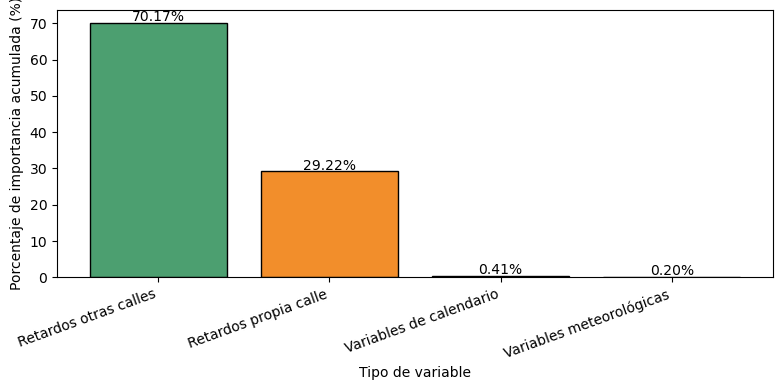

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.bar(resumen_tipos["tipo_variable"], resumen_tipos["porcentaje"],
        color=['#4C9F70', '#F28E2B', '#8E63CE', '#BDBDBD'],
        edgecolor='black')

plt.ylabel("Porcentaje de importancia acumulada (%)")
plt.xlabel("Tipo de variable")

for i, v in enumerate(resumen_tipos["porcentaje"]):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()